### Demonstrate adding in and fitting out the track of a moving point source

This notebook accompanies arxiv:????

This notebook remakes several figures from the paper and demonstrates how to add in and fit moving point sources from up-the-ramp images.

In [1]:
import numpy as np
from astropy.io import fits
from scipy import interpolate
import movingsource
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import rcParams

# Formatting for plots
rcParams['font.size'] = 16
rcParams['lines.linewidth'] = 3.0
rcParams['savefig.facecolor'] = 'white'
rcParams['axes.labelsize'] = 16
rcParams['xtick.direction'] = 'in'
rcParams['xtick.minor.visible'] = True
rcParams['ytick.direction'] = 'in'
rcParams['ytick.right'] = True
rcParams['ytick.minor.visible'] = True

The code block below adds read noise and photon noise to a static image defined by `countrate`.  All units are assumed to be in electrons; `countrate` is in electrons/read.  

In [2]:
def gen_noisy_image(readtimes, resultants, countrate, sig_readnoise, phnoise=True):
    diffs = np.diff(readtimes)[:, None, None]*countrate
    diffs_with_phnoise = np.random.poisson(diffs)
    readnoise_cum = np.random.randn(len(readtimes), *countrate.shape)*sig_readnoise[None, :]
    if phnoise:
        diffs = np.diff(readnoise_cum, axis=0) + diffs_with_phnoise
    else:
        diffs = np.diff(readnoise_cum, axis=0) + diffs
        
    read_values = np.zeros((diffs.shape[0] + 1, *countrate.shape))
    read_values[1:] = np.cumsum(diffs, axis=0)
    
    values_resultants = movingsource.bin_to_resultants(read_values, resultants)
    
    return values_resultants

The code block below adds a moving source to a static background field.  The background field can have randomly positioned stars of random brightnesses.  The static background field then has noise added, and finally the track of a moving object with photon noise.  We then fit for the moving object's path and show how it may be removed from the image.

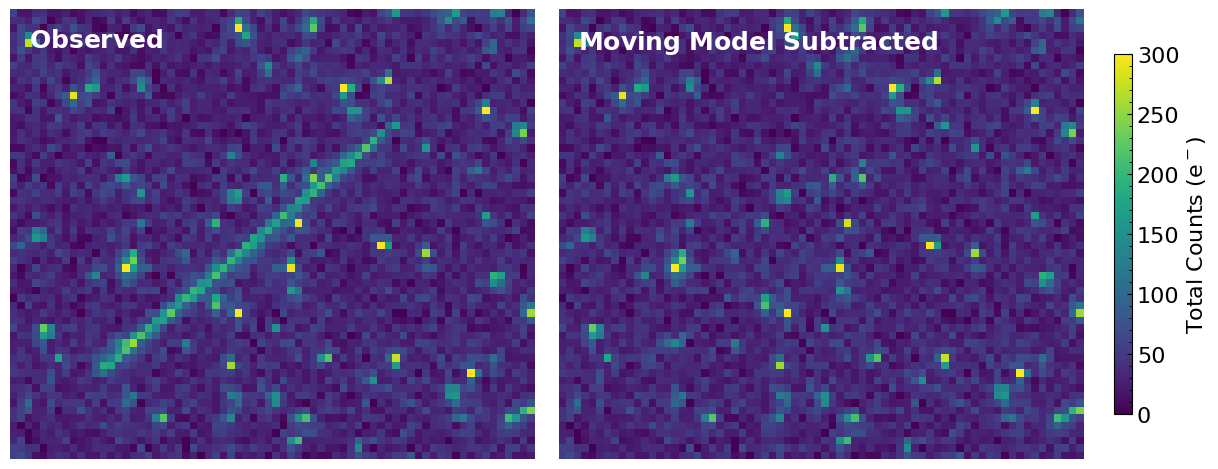

<Figure size 640x480 with 0 Axes>

In [3]:
bkgnd_ctrate = 1    # Background level, counts/read
source_ctrate = 500 # Source flux, counts/read
star_ctrate = 30    # Maximum star flux, counts/read
nstars = 100

phi = np.pi/3.6  # Angle in radians of the moving source's velocity w.r.t. the detector axes
dist = 1.6       # Speed of the source (pixels/read)
x0, y0 = 10, 10  # Position of the moving source at the time of detector reset
outshape = (60, 70)  # Shape of the image to simulate

# Roman ePSF, trimmed to 65x65 (=16x16 true pixels) for computational efficiency.
epsf = fits.open('roman_epsf_centered.fits')[0].data[148:-148, 148:-148]
oversample = 4  # This is a property of the ePSF

# Generate a random field of stars
starfield = np.zeros(outshape)
for i in range(nstars):
    f = interpolate.RectBivariateSpline(np.arange(epsf.shape[0]), 
                                        np.arange(epsf.shape[1]), 
                                        epsf*np.random.rand()*star_ctrate)
    xp = np.random.rand()*outshape[1]
    yp = np.random.rand()*outshape[0]
    movingsource.add_to_image(starfield, f, epsf.shape, xp, yp, oversample=oversample)

# HLWAS MA Table

readtimes = np.arange(1, 33)
# These are the indices of the reads that comprise the resultants (indexed from zero).
resultants = [[0], [1, 2], [3, 4, 5, 6, 7, 8, 9, 10], 
              list(np.arange(11, 27)), [27, 28, 29, 30], [31]]

# Generate read differences with Poisson noise and read noise.

countrate = (bkgnd_ctrate + starfield)*np.ones(outshape)
sig_readnoise = 10*np.ones(outshape)
values_resultants = gen_noisy_image(readtimes, resultants, countrate, sig_readnoise)

Cov = movingsource.Covar(resultants)

# Add a moving object to the 2D image

track = movingsource.MovingTrack(readtimes, resultants, epsf, oversample, outshape)
track.gen_track([phi, dist, x0, y0], flux=source_ctrate, addnoise=True)
values_resultants += track.resultant_values

scaled_diffs = np.diff(values_resultants, axis=0)/Cov.delta_t[:, None, None]

# Now fit a moving object model.  This routine needs a good initial guess; 
# we will give it one that is off by just a little bit (0.2 pixel equivalent
# rms error in all dimensions).

guess_err_pix = 0.2

# Differences between truth and initial guess:
dphi = np.random.randn()*guess_err_pix/(dist*(readtimes[-1] - readtimes[0]))
ddist = dist*np.random.randn()*guess_err_pix/(readtimes[-1] - readtimes[0])
dx0 = np.random.randn()*guess_err_pix
dy0 = np.random.randn()*guess_err_pix

diffs2use = np.ones(scaled_diffs.shape, dtype=bool)

# Fit the moving object's track
parguess = [phi + dphi, dist + ddist, x0 + dx0, y0 + dy0]
track.fit_track(parguess, scaled_diffs, diffs2use, sig_readnoise)

fig = plt.figure(figsize=(12, 4.5))
dx = outshape[1]/outshape[0]*4.5/12
ax1 = fig.add_axes([0, 0, dx, 1])
ax1.axis('off')
ax2 = fig.add_axes([dx + 0.02, 0, dx, 1])
ax2.axis('off')
cax = fig.add_axes([2*dx + 0.045, 0.1, 0.1, 0.8])
cax.axis('off')

ax1.imshow(values_resultants[-1], 
           origin='lower', vmin=0, vmax=300)
ax1.text(2, 57, r"${\bf Observed}$", verticalalignment='top', color='w', fontsize=18)
_im = ax2.imshow(values_resultants[-1] - track.resultant_values[-1],
           origin='lower', vmin=0, vmax=300)

ax2.text(2, 57, r"${\bf Moving~Model~Subtracted}$", verticalalignment='top', color='w', fontsize=18)
plt.colorbar(_im, label='Total Counts (e$^-$)', ax=cax, pad=0, fraction=1, shrink=1, aspect=20)
plt.show()
plt.clf()

Now regenerate a few figures showing the intuition of the modeling using an ePSF normalized to unit peak intensity.

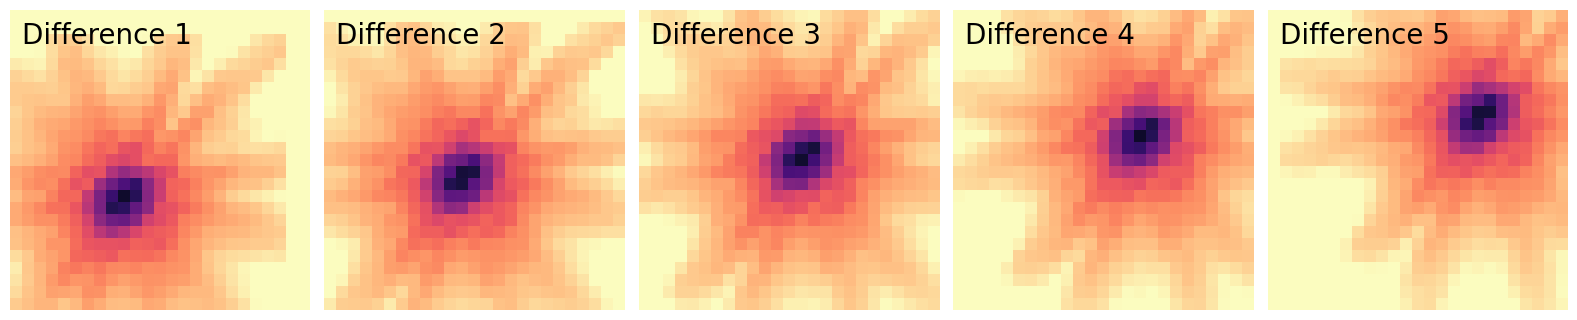

<Figure size 640x480 with 0 Axes>

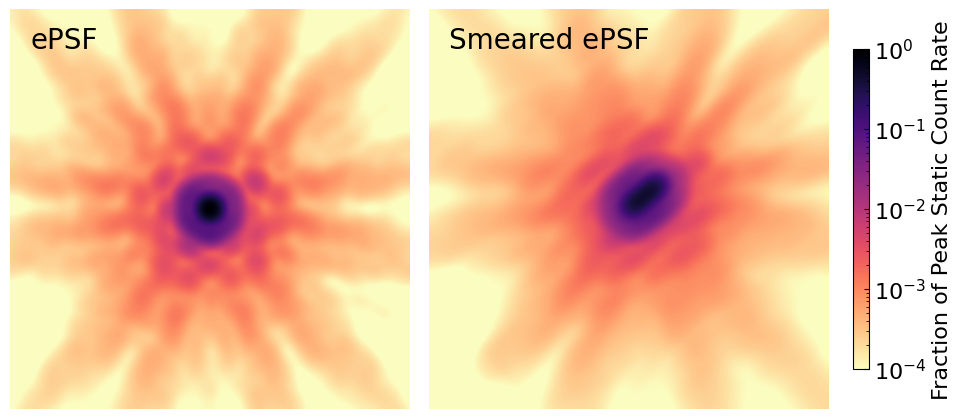

<Figure size 640x480 with 0 Axes>

In [4]:
# Roman ePSF, trimmed to 129x129 (=32x32 true pixels).
epsf = fits.open('roman_epsf_centered.fits')[0].data[116:-116, 116:-116]
epsf /= np.amax(epsf)
oversample = 4

phi = np.pi/3.6
dist = 2.7
outshape = (25, 25)

x0, y0 = 8, 8
readtimes = np.arange(1, 10)
resultants = [[i] for i in range(len(readtimes))]

track = movingsource.MovingTrack(readtimes, resultants, epsf, oversample, outshape)
track.gen_track([phi, dist, x0, y0], flux=1)

s1 = 15*1.04
fig = plt.figure(figsize=(s1, 3))
dx = 0.2/(1 - (0.2 - 3/s1))
for i in range(5):
    ax = fig.add_axes([i*dx, 0, 3/s1, 1])
    diff_value = track.templates_reads[i]
    diff_value[diff_value <= 0] = 1e-100
    ax.imshow(diff_value, origin='lower', norm=LogNorm(vmin=1e-4, vmax=1), cmap='magma_r')
    ax.text(0.5, 23.5, "Difference %d" % (i + 1), color='k', verticalalignment='top', fontsize=20)
    ax.axis('off')
plt.show()
plt.clf()

fig = plt.figure(figsize=(9.5, 4))

dx = 4/9.5
ax1 = fig.add_axes([0, 0, dx, 1])
ax1.imshow(epsf[10:-10, 10:-10], origin='lower', interpolation='bicubic', norm=LogNorm(vmin=1e-4, vmax=1), cmap='magma_r')
ax1.text(5, epsf.shape[1] - 25, "ePSF", horizontalalignment='left', verticalalignment='top', fontsize=20)
ax1.axis('off')

fullim = movingsource.compute_smeared_image(epsf, phi, dist*oversample)
ax2 = fig.add_axes([dx + 0.02, 0, dx, 1])
ax2.text(5, epsf.shape[1] - 25, "Smeared ePSF", horizontalalignment='left', verticalalignment='top', fontsize=20)
ax2.axis('off')
_im = ax2.imshow(fullim[10:-10, 10:-10], origin='lower', interpolation='bicubic', norm=LogNorm(vmin=1e-4, vmax=1), cmap='magma_r')

cax = fig.add_axes([dx*2 + 0.045, 0.1, 0.2, 0.8])
cax.axis('off')
plt.colorbar(_im, label='Fraction of Peak Static Count Rate', ax=cax, pad=0, fraction=1, shrink=1, aspect=20)
plt.show()
plt.clf()

This time, use the full (large) ePSF and generate a track as resultant differences.

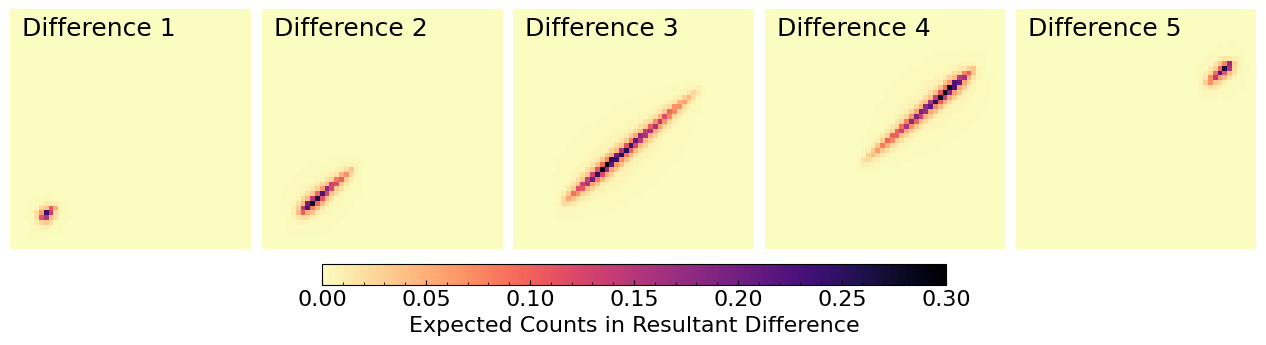

<Figure size 640x480 with 0 Axes>

In [5]:
epsf = fits.open('roman_epsf_centered.fits')[0].data
oversample = 4

readtimes = np.arange(1, 33)
resultants = [[0], [1, 2], [3, 4, 5, 6, 7, 8, 9, 10], 
              list(np.arange(11, 27)), [27, 28, 29, 30], [31]]

dist = 1.6           # Pixels/read
phi = np.pi/3.6      # Angle = 50 degrees
outshape = (50, 50)
x0, y0 = 5, 5        # Start at pixel (5, 5)

track = movingsource.MovingTrack(readtimes, resultants, epsf, oversample, outshape)
track.gen_track([phi, dist, x0, y0], flux=1)

# Machinery to make a tiled plot

s1 = 3*(len(resultants) - 1)*(1 + 0.01*(len(resultants) - 2))*0.8
s2 = 3*6/6*0.8

# 0.2 - 3/s1 is the fraction short
fig = plt.figure(figsize=(s1, s2*7/5))
dx = 0.2/(1 - (0.2 - s2/s1))
for i in range(len(resultants) - 1):
    ax = fig.add_axes([i*dx, 2/7, s2/s1, 5/7])
    _im = ax.imshow(track.templates_resultants[i], origin='lower', vmin=0, vmax=0.3, cmap='magma_r')
    ax.text(2, 48, "Difference %d" % (i + 1), color='k', verticalalignment='top', fontsize=18)
    ax.axis('off')

cax = fig.add_axes([0.25, 0, 0.5, 1.7/7])
cax.axis('off')
plt.colorbar(_im, label='Expected Counts in Resultant Difference', ax=cax, 
             pad=0, fraction=1, shrink=1, aspect=30, orientation='horizontal')
plt.show()
plt.clf()